# NWIS Data Retrieval with Cosecha

This notebook demonstrates how to fetch water resources data from the USGS National Water Information System (NWIS) using the `cosecha`'s reapers and process it with `cosecha`'s data handling utilities.

**What you'll learn:**
- Fetch instantaneous streamflow data from NWIS using the `USGSNWISReaper`
- Understand the structure of NWIS data
- Export data to Parquet format using the reaper's built-in functionality
- Visualize water quality data over time

## 1. Import Required Libraries

We'll use several key libraries in this workflow:
- **cosecha**: Our data harvesting and storage library
- **pandas**: Data manipulation and analysis
- **matplotlib**: Time series visualization

In [16]:
from datetime import datetime
from pathlib import Path

# Cosecha data handling
from cosecha.reaping.nwis import USGSNWISReaper

# Data analysis and visualization
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


## 2. Initialize NWIS Data Source

The **National Water Information System (NWIS)** is maintained by the USGS and provides real-time and historical water data from thousands of monitoring stations across the United States.

### About Cosecha's NWIS Reapers

Cosecha provides `USGSNWISReaper` for NWIS data which uses the `waterdata` API under the hood to access high-frequency measurements.

Parameter codes:
- `00060`: Discharge (cubic feet per second)
- `00065`: Gage height/stage (feet)
- `00045`: Precipitation (inches)

### Advantages of Using Reapers

✓ **Standardized Process**: Easy access to different parameters
✓ **Clean DataFrames**: Returns ready-to-use pandas objects  
✓ **Metadata included**: Automatic tracking of parameters  
✓ **Error handling**: Robust retry logic and validation provided by underlying libraries

## 3. Query NWIS Data

Let's fetch instantaneous streamflow data from a USGS monitoring station.

**Station Details:**
- **Site ID**: 08066500 - Trinity River at Dallas, TX
- **Parameter**: 00060 - Discharge (cubic feet per second)
- **Date Range**: January 2022 (example can be adjusted)

In [17]:
# Fetch instantaneous streamflow data from NWIS using Reaper
print("Fetching instantaneous streamflow data from NWIS...")
print("Site: Trinity River at Dallas, TX (08066500)")
print("Date Range: Jan 1 - Jan 31, 2022\n")

reaper = USGSNWISReaper(
    site_ids=["08066500"],      # USGS site ID
    start_date="2022-01-01",    # Start date (YYYY-MM-DD)
    end_date="2022-01-31",      # End date (YYYY-MM-DD)
    parameter_code="00060"      # Parameter Code for Streamflow
)

df = reaper.reap()

print(f"✓ Retrieved {len(df)} records")
print(f"✓ Date range: {df.index.min()} to {df.index.max()}")

Geopandas not installed. Geometries will be flattened into pandas DataFrames.


Fetching instantaneous streamflow data from NWIS...
Site: Trinity River at Dallas, TX (08066500)
Date Range: Jan 1 - Jan 31, 2022

✓ Retrieved 2881 records
✓ Date range: 0 to 2880


## 4. Process and Explore Results

Let's examine the structure of the retrieved data and check for any data quality issues.

In [18]:
print("Data Structure:")
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"\nData Types:\n{df.dtypes}")

# Display first few records
print("\n" + "="*70)
print("First 5 records:")
print("="*70)
df.head()

Data Structure:
Shape: (2881, 11)
Columns: ['time_series_id', 'monitoring_location_id', 'parameter_code', 'statistic_id', 'time', 'value', 'unit_of_measure', 'approval_status', 'qualifier', 'last_modified', 'continuous_id']

Data Types:
time_series_id                         object
monitoring_location_id                 object
parameter_code                         object
statistic_id                           object
time                      datetime64[ns, UTC]
value                                   int64
unit_of_measure                        object
approval_status                        object
qualifier                              object
last_modified             datetime64[ns, UTC]
continuous_id                          object
dtype: object

First 5 records:


,time_series_id,monitoring_location_id,parameter_code,statistic_id,time,value,unit_of_measure,approval_status,qualifier,last_modified,continuous_id
0,5d8132ec1a204ff9a6ac6f58e55bb8a0,USGS-08066500,00060,00011,2022-01-01 00:00:00+00:00,2320,ft^3/s,Approved,None,2025-09-06 02:52:21.863287+00:00,cd24d2f4-8d28-441d-a137-ad5154d8aa02
1,5d8132ec1a204ff9a6ac6f58e55bb8a0,USGS-08066500,00060,00011,2022-01-01 00:15:00+00:00,2310,ft^3/s,Approved,None,2025-09-06 02:52:21.863287+00:00,32e493f3-a874-44bd-b9ac-257918d913d2
2,5d8132ec1a204ff9a6ac6f58e55bb8a0,USGS-08066500,00060,00011,2022-01-01 00:30:00+00:00,2310,ft^3/s,Approved,None,2025-09-06 02:52:21.863287+00:00,2e266246-9c91-45a1-9927-cedacc06a698
3,5d8132ec1a204ff9a6ac6f58e55bb8a0,USGS-08066500,00060,00011,2022-01-01 00:45:00+00:00,2320,ft^3/s,Approved,None,2025-09-06 02:52:21.863287+00:00,0f3edfe6-ef07-4875-81b1-6138fe335141
4,5d8132ec1a204ff9a6ac6f58e55bb8a0,USGS-08066500,00060,00011,2022-01-01 01:00:00+00:00,2300,ft^3/s,Approved,None,2025-09-06 02:52:21.863287+00:00,30f914ea-9822-4181-8140-361700bf625d


In [19]:
print("\n" + "="*70)
print("Data Quality Summary:")
print("="*70)
print(f"\nMissing values:\n{df.isnull().sum()}")

print("\n" + "="*70)
print("Streamflow Statistics (cubic feet per second):")
print("="*70)
# Get discharge value column
discharge_col = 'value'
if discharge_col in df.columns:
    print(df[discharge_col].describe())
    print(f"\nCharacteristics:")
    print(f"  Median flow: {df[discharge_col].median():.1f} cfs")
    print(f"  Peak flow: {df[discharge_col].max():.1f} cfs")
    print(f"  Min flow: {df[discharge_col].min():.1f} cfs")


Data Quality Summary:

Missing values:
time_series_id               0
monitoring_location_id       0
parameter_code               0
statistic_id                 0
time                         0
value                        0
unit_of_measure              0
approval_status              0
qualifier                 2881
last_modified                0
continuous_id                0
dtype: int64

Streamflow Statistics (cubic feet per second):
count    2881.000000
mean     1868.746963
std       852.349892
min      1340.000000
25%      1510.000000
50%      1570.000000
75%      1680.000000
max      5810.000000
Name: value, dtype: float64

Characteristics:
  Median flow: 1570.0 cfs
  Peak flow: 5810.0 cfs
  Min flow: 1340.0 cfs


## 5. Save to Parquet Format

The reaper's `sow_to_parquet` method writes the data to Apache Parquet format, which provides:
- **Efficient compression**: Smaller file sizes than CSV
- **Column-oriented storage**: Fast queries on specific fields
- **Binary format**: Preserves data types and datetime precision
- **Wide compatibility**: Supported by pandas, Apache Spark, and other tools

The sower automatically generates timestamped filenames to avoid conflicts if a filename is not provided.

In [20]:
# Create output directory if it doesn't exist
output_dir = Path("./data")
output_dir.mkdir(exist_ok=True)

# Save the harvested data to Parquet
output_path = reaper.sow_to_parquet(file_path=output_dir / "streamflow_08066500_202201.parquet")

print(f"✓ Data saved successfully!")
print(f"  Path: {output_path}")
print(f"  File size: {Path(output_path).stat().st_size:,} bytes")

✓ Data saved successfully!
  Path: data/streamflow_08066500_202201.parquet
  File size: 144,641 bytes


## 6. Read and Verify Saved Data

Let's read the Parquet file back to verify everything was saved correctly.

In [21]:
# Read the Parquet file back
df_loaded = pd.read_parquet(output_path)

print("Verification:")
print(f"✓ Records loaded: {len(df_loaded)}")
print(f"✓ Columns: {list(df_loaded.columns)}")
print(f"✓ Date range preserved: {df_loaded.index.min()} to {df_loaded.index.max()}")
print(f"\nData types after loading:")
print(df_loaded.dtypes)
print(f"\nFirst 3 records from saved file:")
df_loaded.head(3)

Verification:
✓ Records loaded: 2881
✓ Columns: ['time_series_id', 'monitoring_location_id', 'parameter_code', 'statistic_id', 'time', 'value', 'unit_of_measure', 'approval_status', 'qualifier', 'last_modified', 'continuous_id']
✓ Date range preserved: 0 to 2880

Data types after loading:
time_series_id                         object
monitoring_location_id                 object
parameter_code                         object
statistic_id                           object
time                      datetime64[ns, UTC]
value                                   int64
unit_of_measure                        object
approval_status                        object
qualifier                              object
last_modified             datetime64[ns, UTC]
continuous_id                          object
dtype: object

First 3 records from saved file:


,time_series_id,monitoring_location_id,parameter_code,statistic_id,time,value,unit_of_measure,approval_status,qualifier,last_modified,continuous_id
0,5d8132ec1a204ff9a6ac6f58e55bb8a0,USGS-08066500,00060,00011,2022-01-01 00:00:00+00:00,2320,ft^3/s,Approved,None,2025-09-06 02:52:21.863287+00:00,cd24d2f4-8d28-441d-a137-ad5154d8aa02
1,5d8132ec1a204ff9a6ac6f58e55bb8a0,USGS-08066500,00060,00011,2022-01-01 00:15:00+00:00,2310,ft^3/s,Approved,None,2025-09-06 02:52:21.863287+00:00,32e493f3-a874-44bd-b9ac-257918d913d2
2,5d8132ec1a204ff9a6ac6f58e55bb8a0,USGS-08066500,00060,00011,2022-01-01 00:30:00+00:00,2310,ft^3/s,Approved,None,2025-09-06 02:52:21.863287+00:00,2e266246-9c91-45a1-9927-cedacc06a698


## 7. Visualize NWIS Data

Let's create a time series plot of the streamflow data to visualize discharge patterns over the month.

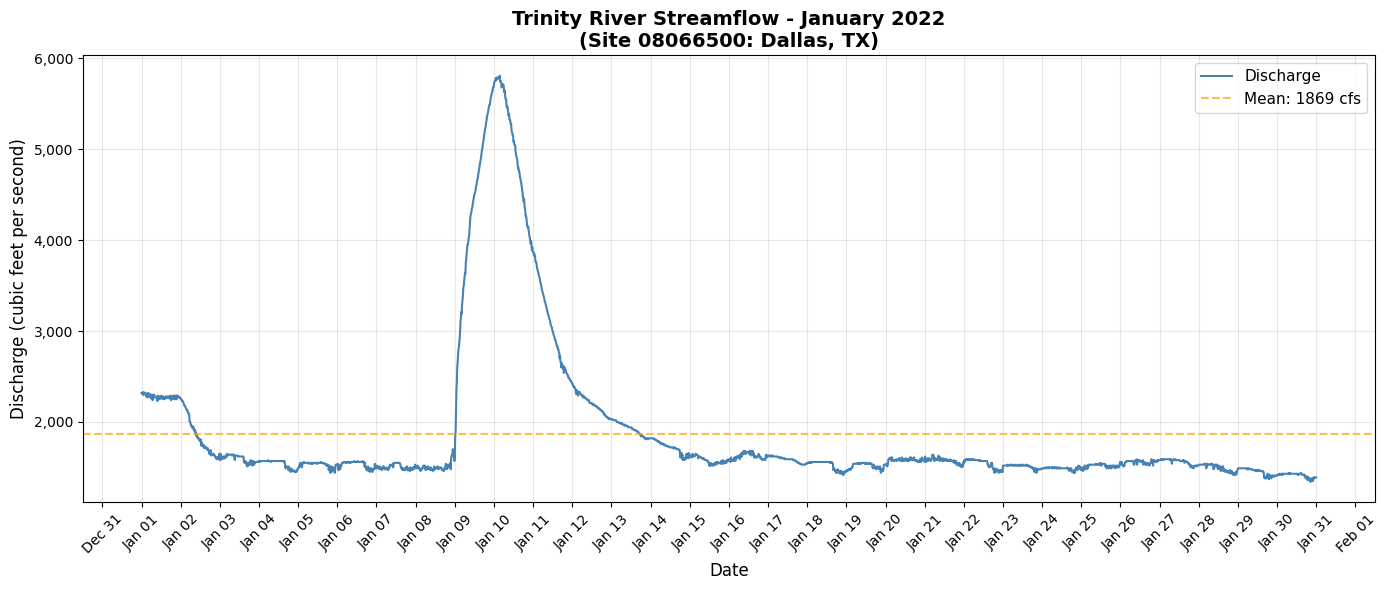


Flow characteristics:
  Mean discharge: 1868.7 cfs
  Peak discharge: 5810.0 cfs
  Min discharge: 1340.0 cfs
  Std Dev: 852.3 cfs


In [22]:
df['time'] = pd.to_datetime(df['time'])

fig, ax = plt.subplots(figsize=(14, 6))

value_col = 'value'
if value_col in df.columns:
    ax.plot(df['time'], df[value_col], linewidth=1.5, color='steelblue', label='Discharge')
    
    ax.set_xlabel('Date', fontsize=12)
    ax.set_ylabel('Discharge (cubic feet per second)', fontsize=12)
    ax.set_title('Trinity River Streamflow - January 2022\n(Site 08066500: Dallas, TX)', 
                 fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    # 3. Force the locator to trigger exactly once per day
    ax.xaxis.set_major_locator(mdates.DayLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    plt.xticks(rotation=45)
    
    # Add statistics to plot
    mean_flow = df[value_col].mean()
    max_flow = df[value_col].max()
    ax.axhline(y=mean_flow, color='orange', linestyle='--', alpha=0.7, label=f'Mean: {mean_flow:.0f} cfs')
    
    ax.legend(fontsize=11)
    
    # Format y-axis with thousands separator
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nFlow characteristics:")
    print(f"  Mean discharge: {mean_flow:.1f} cfs")
    print(f"  Peak discharge: {max_flow:.1f} cfs")
    print(f"  Min discharge: {df[value_col].min():.1f} cfs")
    print(f"  Std Dev: {df[value_col].std():.1f} cfs")

## Summary

You've successfully completed the NWIS data workflow! Here's what you learned:

### Key Takeaways

1. **Data Retrieval**: `USGSNWISReaper` leverages the `waterdata` module to provide access to USGS NWIS data with automatic API handling
2. **Instantaneous Data**: The reaper retrieves high-frequency measurements (5-min to hourly depending on station)
3. **Efficient Storage**: Direct integration with Parquet writing saves data in a compressed, queryable format
4. **Data Pipeline**: Reap → Save → Analyze (as demonstrated here)

### Next Steps

- **Multiple parameters**: Pass different parameter codes for stage or precipitation
- **Multiple sites**: Fetch data from multiple USGS stations in one call by providing multiple site IDs
- **Different writers**: Use `sow_to_csv` or other output formats
- **Automation**: Schedule this notebook to run daily for continuous data collection
- **Advanced analysis**: Combine with xarray for multi-dimensional analysis of gridded data

### Resources

- [USGS NWIS Web Services](https://waterservices.usgs.gov/)
- [dataretrieval Documentation](https://github.com/DOI-USGS/dataretrieval-python)
- [Cosecha Documentation](https://dewberry.github.io/cosecha/)
- [Apache Parquet Format](https://parquet.apache.org/)